In [1]:
%pylab inline
#import gwpy
import copy
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import numpy as np
import astropy.units as u
import astropy.cosmology
import swyft
from sklearn.preprocessing import StandardScaler
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning import loggers as pl_loggers
import torch
from astropy.cosmology import Planck18, z_at_value, Planck13, Planck15
from scipy.integrate import quad
from scipy import interpolate
from astropy.constants import pc, c
import scipy
import jax
#from jaxinterp2d import interp2d
import seaborn as sns
from jax import jit
import jax.numpy as jnp
from jax import device_get
import numpyro
import arviz as az
import numpyro.distributions as dist
#from gwpy.timeseries import TimeSeries
from numpyro.infer import MCMC, NUTS
import torch.nn as nn
import torch.nn.functional as F
np.random.seed(3407)
jax.config.update("jax_enable_x64", True)
sns.set(style='ticks', context='notebook', font='serif', 
        font_scale=1.5, palette='deep')
rc_params = {'backend': 'pdf',
             'axes.labelsize': 24,
             'axes.titlesize': 32,
             'font.size': 18,
             'legend.fontsize': 18,
             'xtick.labelsize': 24,
             'ytick.labelsize': 24,
             'font.family': 'serif',
             'font.sans-serif': ['Bitstream Vera Sans'],
             'font.serif': ['Times New Roman'],
             'text.usetex':True,
            }
plt.rcParams["text.usetex"] = "true"

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
__all__ = ['Bounded_2d_kde', 'Bounded_1d_kde', 'kdeplot']

import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss
import seaborn as sns
import pandas as pd

class Bounded_1d_kde(ss.gaussian_kde):
    """ Represents a one-dimensional Gaussian kernel density estimator
    for a probability distribution function that exists on a bounded
    domain.

    Authorship: Ben Farr, LIGO
    """

    def __init__(self, pts, x_min=None, x_max=None, *args, **kwargs):
        """Initialize with the given bounds.  Either ``low`` or
        ``high`` may be ``None`` if the bounds are one-sided.  Extra
        parameters are passed to :class:`gaussian_kde`.

        :param x_min: The lower x domain boundary.

        :param x_max: The upper x domain boundary.
        """
        pts = np.atleast_1d(pts)

        assert pts.ndim == 1, 'Bounded_1d_kde can only be one-dimensional'

        super(Bounded_1d_kde, self).__init__(pts.T, *args, **kwargs)

        self._x_min = x_min
        self._x_max = x_max

    @property
    def x_min(self):
        """The lower bound of the x domain."""
        return self._x_min
    @property
    def x_max(self):
        """The upper bound of the x domain."""
        return self._x_max

    def evaluate(self, pts):
        """Return an estimate of the density evaluated at the given
        points."""
        pts = np.atleast_1d(pts)
        assert pts.ndim == 1, 'points must be one-dimensional'

        x = pts.T
        pdf = super(Bounded_1d_kde, self).evaluate(pts.T)
        if self.x_min is not None:
            pdf += super(Bounded_1d_kde, self).evaluate(2*self.x_min - x)

        if self.x_max is not None:
            pdf += super(Bounded_1d_kde, self).evaluate(2*self.x_max - x)

        return pdf

    def __call__(self, pts):
        pts = np.atleast_1d(pts)
        out_of_bounds = np.zeros(pts.shape[0], dtype='bool')

        if self.x_min is not None:
            out_of_bounds[pts < self.x_min] = True
        if self.x_max is not None:
            out_of_bounds[pts > self.x_max] = True

        results = self.evaluate(pts)
        results[out_of_bounds] = 0.
        return results


# The following routine, Bounded_2d_kde, was copied from
# https://git.ligo.org/publications/gw190412/gw190412-discovery/-/blob/851f91431b7c36e7ea66fa47e8516f2aef9d7daf/scripts/bounded_2d_kde.py
class Bounded_2d_kde(ss.gaussian_kde):
    r"""Represents a two-dimensional Gaussian kernel density estimator
    for a probability distribution function that exists on a bounded
    domain."""

    def __init__(self, pts, x_min=None, x_max=None, y_min=None, y_max=None,
                 *args, **kwargs):
        """Initialize with the given bounds.  Either ``low`` or
        ``high`` may be ``None`` if the bounds are one-sided.  Extra
        parameters are passed to :class:`gaussian_kde`.

        :param x_min: The lower x domain boundary.

        :param x_max: The upper x domain boundary.

        :param y_min: The lower y domain boundary.

        :param y_max: The upper y domain boundary.
        """
        pts = np.atleast_2d(pts)

        assert pts.ndim == 2, 'Bounded_kde can only be two-dimensional'

        super(Bounded_2d_kde, self).__init__(pts.T, *args, **kwargs)

        self._x_min = x_min
        self._x_max = x_max
        self._y_min = y_min
        self._y_max = y_max

    @property
    def x_min(self):
        """The lower bound of the x domain."""
        return self._x_min

    @property
    def x_max(self):
        """The upper bound of the x domain."""
        return self._x_max

    @property
    def y_min(self):
        """The lower bound of the y domain."""
        return self._y_min

    @property
    def y_max(self):
        """The upper bound of the y domain."""
        return self._y_max

    def evaluate(self, pts):
        """Return an estimate of the density evaluated at the given
        points."""
        pts = np.atleast_2d(pts)
        assert pts.ndim == 2, 'points must be two-dimensional'

        x, y = pts.T
        pdf = super(Bounded_2d_kde, self).evaluate(pts.T)
        if self.x_min is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_min - x, y])
        if self.x_max is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_max - x, y])
        if self.y_min is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([x, 2*self.y_min - y])
        if self.y_max is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([x, 2*self.y_max - y])
        if self.x_min is not None:
            if self.y_min is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_min - x,
                                                             2*self.y_min - y])
            if self.y_max is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_min - x,
                                                             2*self.y_max - y])
        if self.x_max is not None:
            if self.y_min is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_max - x,
                                                             2*self.y_min - y])
            if self.y_max is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_max - x,
                                                             2*self.y_max - y])
        return pdf

    def __call__(self, pts):
        pts = np.atleast_2d(pts)
        out_of_bounds = np.zeros(pts.shape[0], dtype='bool')

        if self.x_min is not None:
            out_of_bounds[pts[:, 0] < self.x_min] = True
        if self.x_max is not None:
            out_of_bounds[pts[:, 0] > self.x_max] = True
        if self.y_min is not None:
            out_of_bounds[pts[:, 1] < self.y_min] = True
        if self.y_max is not None:
            out_of_bounds[pts[:, 1] > self.y_max] = True

        results = self.evaluate(pts)
        results[out_of_bounds] = 0.
        return results


# ############################################################################
# PLOTTING

def kdeplot_2d_clevels(xs, ys, levels=10, fill=False, n_grid=128, **kws):
    """ Plot contours at specified credible levels.

    Arguments
    ---------
    xs: array
        samples of the first variable.
    ys: array
        samples of the second variable, drawn jointly with `xs`.
    levels: float, array
        if float, interpreted as number of credible levels to be equally 
        spaced between (0, 1); if array, interpreted as list of credible
        levels.
    x_min: float
        lower bound for abscissa passed to Bounded_2d_kde (optional).
    xigh: float
        upper bound for abscissa passed to Bounded_2d_kde (optional).
    y_min: float
        lower bound for ordinate passed to Bounded_2d_kde (optional).
    y_max: float
        upper bound for ordinate passed to Bounded_2d_kde (optional).
    ax: Axes
        matplotlib axes on which to plot (optional).
    kwargs:
        additional arguments passed to plt.contour().
    """
    try:
        xs = xs.values.astype(float)
        ys = ys.values.astype(float)
    except AttributeError:
        pass

    if np.all(~np.isfinite(xs)) or np.all(~np.isfinite(ys)):
        return None
    
    # construct credible levels
    try:
        len(levels)
        f = 1 - np.array(levels)
    except TypeError:
        f = np.linspace(0, 1, levels+1, endpoint=True)[1:-1]
    if fill:
        # f = np.concatenate([f, [1]])
        kws['extend'] = 'max'
    
    # estimate bounded KDE from samples
    if kws.get('auto_bound', False):
        kws['x_min'] = min(xs)
        kws['x_max'] = max(xs)
        kws['y_min'] = min(ys)
        kws['y_max'] = max(ys)
    ks = ['x_min', 'x_max', 'y_min', 'y_max', 'bw_method', 'weights']
    kde_kws = {k: kws.pop(k, None) for k in ks}
    k = Bounded_2d_kde(np.column_stack((xs, ys)), **kde_kws)
    
    # evaluate KDE on all points
    p = k(np.column_stack((xs, ys)))
    
    # the levels passed to the contour function have to be the
    # values of the KDE at corresponding to the quantiles
    # first get the order of the samples sorted by KDE value
    # then find the values that correspond to the thresholds
    i = np.argsort(p)
    l = np.array([p[i[min(int(np.round(ff*len(p))), len(i)-1)]] for ff in f])
    
    # construct grid of x and y values based on the
    # range of the samples
    x_hi, x_lo = np.percentile(xs, 99), np.percentile(xs, 1)
    y_hi, y_lo = np.percentile(ys, 99), np.percentile(ys, 1)
    
    Dx = x_hi - x_lo
    Dy = y_hi - y_lo

    x = np.linspace(x_lo-0.1*Dx, x_hi+0.1*Dx, n_grid)
    y = np.linspace(y_lo-0.1*Dy, y_hi+0.1*Dy, n_grid)

    # construct grids and evaluate KDE
    XS, YS = np.meshgrid(x, y, indexing='ij')
    ZS = k(np.column_stack((XS.flatten(), YS.flatten()))).reshape(XS.shape)

    ax = kws.pop('ax', plt.gca())
    p = kws.get('cmap', kws.pop('palette', None))
    if p is not None:
        kws['colors'] = None
        kws['cmap'] = p
    else:
        kws['colors'] = kws.get('colors', 
                                [kws.pop('color', kws.pop('c', None)),])
    if fill:
        ax.contourf(XS, YS, ZS, levels=l, **kws)
    else:
        ax.contour(XS, YS, ZS, levels=l, **kws)


def kdeplot(x, y=None, **kws):
    
    if np.all(~np.isfinite(x)):
        return None

    if 'hue' in kws:
        hues = kws.pop('hue')
        hues_unique = sorted(hues.unique())
        n_hues = len(hues_unique)
        
        if 'palette' in kws:
            palette = sns.color_palette(kws.pop('palette'), n_colors=n_hues)
        else:
            # attempt to use seaborn's logic for determining the color palette
            # (this will fail if seaborn changes it's internal API)
            try:
                from seaborn.distributions import _DistributionPlotter
                df = pd.DataFrame(dict(x=x, y=y, hue=hues))
                if y is None:
                    df = df.drop(columns='y')
                    v = dict(x='x', hue='hue')
                else:
                    v = dict(x='x', y='y', hue='hue')
                dp = _DistributionPlotter(data=df, variables=v)
                palette = [dp._hue_map(l) for l in dp._hue_map.levels]
            except Exception:
                if pd.api.types.is_numeric_dtype(hues_unique):
                    # Numeric: Use a sequential palette
                    palette = sns.color_palette("ch:", n_colors=n_hues)
                else:
                    # Categorical: Use a qualitative palette
                    palette = sns.color_palette("deep", n_colors=n_hues)

        for hue, color in zip(hues_unique, palette):
            xs_hue = x[hues == hue]
            if y is None:
                ys_hue = None
            else:
                ys_hue = y[hues == hue]
            kdeplot(xs_hue, ys_hue, **kws, color=color)
            plt.plot([], [], c=color, label=hue)
        plt.legend();
        return
    
    if y is not None:
        return kdeplot_2d_clevels(x, y, **kws)
    
    if kws.pop('auto_bound', False):
        kws['x_min'] = min(x)
        kws['x_max'] = max(x)
    kde_kws = {k: kws.pop(k, None) for k in 
               ['x_min', 'x_max', 'bw_method', 'weights']}
    k = Bounded_1d_kde(x, **kde_kws)
    
    x_hi, x_lo = np.percentile(x, 99), np.percentile(x, 1)
    
    Dx = x_hi - x_lo
    xgrid = np.linspace(x_lo-0.1*Dx, x_hi+0.1*Dx, kws.pop('n_grid', 128))
    ygrid = k(xgrid)
    ax = kws.pop('ax', plt.gca())
    ax.plot(xgrid, ygrid, **kws)
    
    if kws.get('fill', False):
        alpha = kws.get('alpha', 0.5)
        ax.fill_between(xgrid, 0, ygrid, alpha=alpha, **kws)

In [3]:
# Define simulator parameters
f_low = 10
f_high = 200
Delta_f = 1./32
N_bins = int((f_high-f_low)/Delta_f) + 1
freq = np.linspace(f_low, f_high+Delta_f, N_bins)
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100

# Define Simulator
class Simulator(swyft.Simulator):
    def __init__(self, fref, psd, gamma, T_obs, Nbins=len(freq), bounds=None):
        super().__init__()
        self.fref      = fref
        self.psd       = psd
        self.gamma     = gamma
        self.T_obs     = T_obs
        
        self.transform_samples = swyft.to_numpy32
        self.Nbins = Nbins
        self.freq = np.linspace(f_low, f_high, N_bins)
        self.sample_z = swyft.RectBoundSampler([stats.uniform(-15, 7), 
                                                stats.uniform(-5,10)], #alpha
                                                bounds = bounds) #bounds changes range of the prior

    def psd_interp(self):
        return scipy.interpolate.interp1d(self.psd[:,0], self.psd[:,1])(self.freq)
    
    def gamma_interp(self):
        return scipy.interpolate.interp1d(self.gamma[:, 0], self.gamma[:, 1])(self.freq)
    
    def sigma(self):
        numerator = (20*pi**2*self.freq**3)**2 * self.psd_interp()**2
        denomenator = (3*H0**2)**2 * 8*self.gamma_interp()**2
        #denomenator = (3*H0**2)**2 * 8
        T = 1/(self.freq[1]-self.freq[0])
        N = 2*self.T_obs // T - 1
        return np.sqrt(numerator/denomenator/N)
    
    def C_groundtruth(self, z):
        Omega_ref = 10**z[0]
        alpha     = z[1]
        C_hat_ij = Omega_ref * (self.freq/self.fref)**alpha
        return C_hat_ij
    
    def build(self, graph):
        z = graph.node('z', self.sample_z)
        m = graph.node('m', self.C_groundtruth, z)
        x = graph.node("x", lambda m: m + np.random.normal(0, self.sigma()), m)
        #sigma = graph.node('sigma',self.sigma)

def make_model(f, C_ij, sigma_ij):
    f_ref = 25
    # Priors

    log10_Omega = numpyro.sample("log10_Omega", dist.Uniform(-15, -8),  sample_shape=(1,),rng_key=jax.random.PRNGKey(3407))
    alpha = numpyro.sample("alpha", dist.Uniform(-4, 4),  sample_shape=(1,),rng_key=jax.random.PRNGKey(3407))
    Omega = log10_Omega
    # Convert to linear space
    Omega_cosmo = 10**log10_Omega * (f / f_ref)**alpha
    
    # Gaussian log-likelihood
    logp = -0.5*jnp.sum(((C_ij - Omega_cosmo) / sigma_ij)**2)
    numpyro.factor("log_likelihood", logp)




In [4]:
def preprocess_whiten(y_raw, sigma_raw):
    """
    y_raw: (batch_size, 4096)
    sigma_raw: (4096,) or (batch_size, 4096)
    """

    # 1. Whitening
    weight = sigma_raw**-2/(np.sum(sigma_raw**-2))
    y_whitened = y_raw# * weight

    # 2. Log compression (可选，但通常很有用)
    y_log = np.log10(np.abs(y_whitened)/sigma_raw)
    #y_log = np.log10(np.abs(y_raw/sigma_raw))
    # MIN = np.min(y_log, axis=-1).reshape([-1, 1])
    # MAX = np.max(y_log, axis=-1).reshape([-1, 1])
    # y_log = (y_log - MIN)/(MAX - MIN)
    return y_log

In [5]:
# Define simulator parameters
f_low = 10
f_high = 200
N_bins = 2048
freq = np.linspace(f_low, f_high, N_bins)
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100

# Sample from Simulator

fref = 25
CE_PSD = np.genfromtxt("data/cosmic_explorer_40km_for_paper.txt")
CE_PSD[0, 0]  = 4.99999999999999999
CE_PSD[:, 1] = CE_PSD[:, 1]**2
gamma_HL = np.genfromtxt("data/gamma_HL.txt")
T_obs = 365 * 24 * 3600



sim = Simulator(fref, CE_PSD, gamma_HL, T_obs, bounds=None)
sigma = sim.sigma()

# Sample from Simulator

n_samples = 50_000

sims = sim.sample(N = n_samples)
sims['x'] = preprocess_whiten(sims['x'] , sigma)


  0%|          | 0/50000 [00:00<?, ?it/s]

In [6]:
def preprocess_whiten(y_raw, sigma_raw):
    """
    y_raw: (batch_size, 4096)
    sigma_raw: (4096,) or (batch_size, 4096)
    """

    # 1. Whitening
    weight = sigma_raw**-2/(np.sum(sigma_raw**-2))
    y_whitened = y_raw# * weight

    # 2. Log compression 
    y_log = np.log10(np.abs(y_whitened)/sigma_raw)
   
    return y_log

In [7]:
test_data = sim.sample(conditions={'z':[-8.5, -3]})
original_test_data = copy.deepcopy(test_data['x'])
test_data['x'] = test_data['x'].reshape([1, 2048])
test_data['x'] = preprocess_whiten(test_data['x'] , sigma)
test_data['x'] = test_data['x'][0]

In [8]:
def make_model(f, C_ij, sigma_ij):
    f_ref = 25
    # prior
    Omega = numpyro.sample('Omega_alpha', dist.LogUniform(1e-15,1e-8), sample_shape=(1,),rng_key=jax.random.PRNGKey(3407))

    alpha = numpyro.sample('alpha', dist.Uniform(-5,5), sample_shape=(1,),rng_key=jax.random.PRNGKey(3407))
  
    Omega_cosmo =   Omega * (f / f_ref)**alpha
    logp = -jnp.sum((C_ij - Omega_cosmo)**2/sigma_ij**2)/2

    numpyro.factor('log_likelihood', logp)


In [9]:

nmcmc = 1000
nchain = 4


kernel = NUTS(make_model)
mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
mcmc.run(jax.random.PRNGKey(3407), sim.freq, original_test_data, sigma)

/var/folders/63/39kkwt414rv8gx91d72hdt240000gn/T/ipykernel_37464/2418426783.py:6: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
sample: 100%|██████████| 2000/2000 [00:00<00:00, 3226.86it/s, 15 steps of size 1.01e-05. acc. prob=0.87]


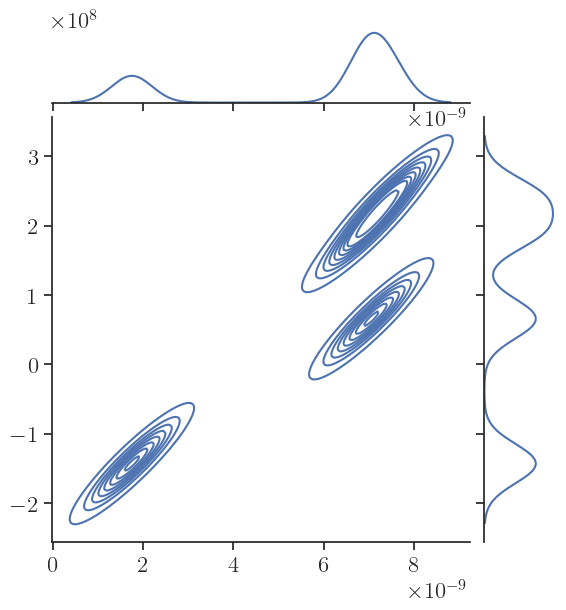

In [10]:
result = az.from_numpyro(mcmc)
Omega_MCMC = np.asarray(result['posterior']['Omega_alpha']).reshape([-1])
alpha_MCMC = np.asarray(result['posterior']['alpha']).reshape([-1])
sns.jointplot(x=Omega_MCMC, y=alpha_MCMC, kind="kde")

In [11]:
test_data = sim.sample(conditions={'z':[-8.5, 0]})
original_test_data = copy.deepcopy(test_data['x'])
test_data['x'] = test_data['x'].reshape([1, 2048])
test_data['x'] = preprocess_whiten(test_data['x'] , sigma)
test_data['x'] = test_data['x'][0]

In [12]:
nmcmc = 1000
nchain = 4

kernel = NUTS(make_model)
mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
mcmc.run(jax.random.PRNGKey(3407), sim.freq, original_test_data, sigma)

/var/folders/63/39kkwt414rv8gx91d72hdt240000gn/T/ipykernel_37464/1574407153.py:5: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
sample: 100%|██████████| 2000/2000 [00:00<00:00, 2777.19it/s, 7 steps of size 5.92e-03. acc. prob=0.94] 


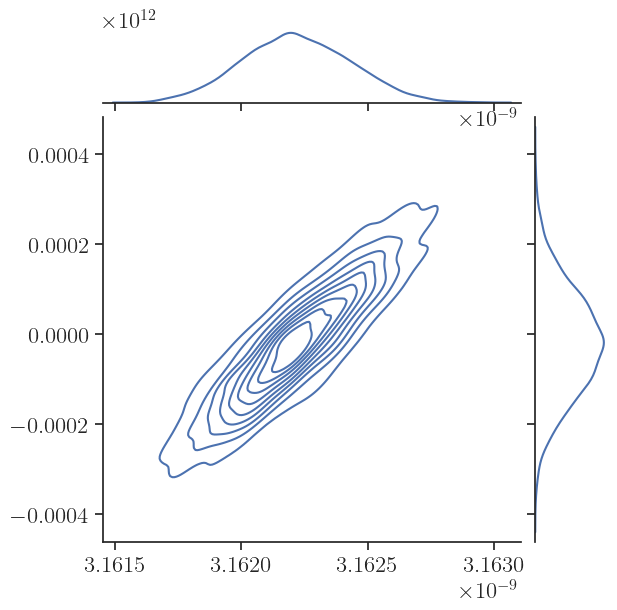

In [13]:
result = az.from_numpyro(mcmc)
Omega_MCMC = np.asarray(result['posterior']['Omega_alpha']).reshape([-1])
alpha_MCMC = np.asarray(result['posterior']['alpha']).reshape([-1])
sns.jointplot(x=Omega_MCMC, y=alpha_MCMC, kind="kde")

In [14]:
np.std(Omega_MCMC), np.std(alpha_MCMC)

(2.1286176062386513e-13, 0.00011833134823713706)

In [15]:
test_data = sim.sample(conditions={'z':[-8.5, 3/2]})
original_test_data = copy.deepcopy(test_data['x'])
test_data['x'] = test_data['x'].reshape([1, 2048])
test_data['x'] = preprocess_whiten(test_data['x'] , sigma)
test_data['x'] = test_data['x'][0]

In [16]:
nmcmc = 1000
nchain = 4

kernel = NUTS(make_model)
mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
mcmc.run(jax.random.PRNGKey(3407), sim.freq, original_test_data, sigma)

/var/folders/63/39kkwt414rv8gx91d72hdt240000gn/T/ipykernel_37464/1574407153.py:5: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
sample: 100%|██████████| 2000/2000 [00:00<00:00, 3799.98it/s, 3 steps of size 1.79e-02. acc. prob=0.91]


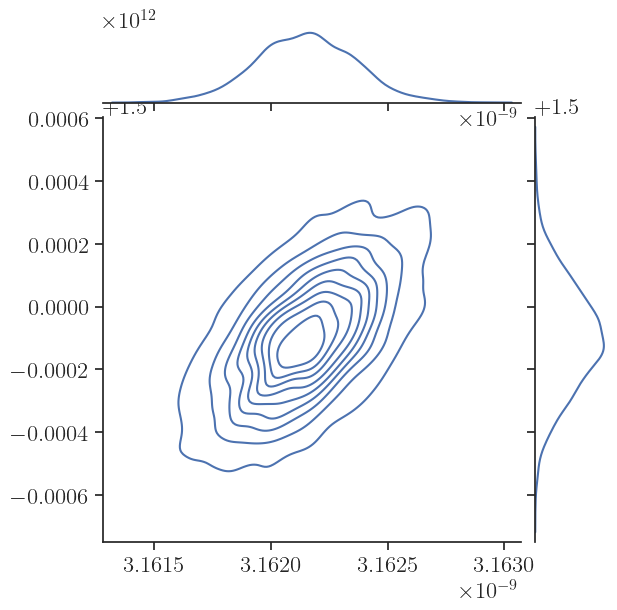

In [17]:
result = az.from_numpyro(mcmc)
Omega_MCMC = np.asarray(result['posterior']['Omega_alpha']).reshape([-1])
alpha_MCMC = np.asarray(result['posterior']['alpha']).reshape([-1])
sns.jointplot(x=Omega_MCMC, y=alpha_MCMC, kind="kde")

In [18]:
np.std(Omega_MCMC), np.std(alpha_MCMC)

(2.125563592339848e-13, 0.00016878156892386698)

In [19]:
test_data = sim.sample(conditions={'z':[-14.999, 1]})
original_test_data = copy.deepcopy(test_data['x'])
test_data['x'] = test_data['x'].reshape([1, 2048])
test_data['x'] = preprocess_whiten(test_data['x'] , sigma)
test_data['x'] = test_data['x'][0]

In [20]:
nmcmc = 1000
nchain = 4

kernel = NUTS(make_model)
mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
mcmc.run(jax.random.PRNGKey(3407), sim.freq, original_test_data, sigma)

/var/folders/63/39kkwt414rv8gx91d72hdt240000gn/T/ipykernel_37464/1574407153.py:5: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup = nmcmc, num_samples = nmcmc, num_chains = nchain)
sample: 100%|██████████| 2000/2000 [00:00<00:00, 3688.87it/s, 7 steps of size 5.92e-01. acc. prob=0.75] 


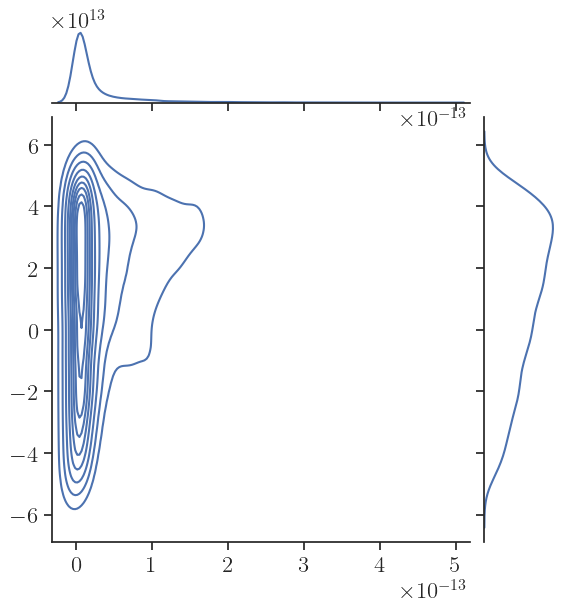

In [21]:
result = az.from_numpyro(mcmc)
Omega_MCMC = np.asarray(result['posterior']['Omega_alpha']).reshape([-1])
alpha_MCMC = np.asarray(result['posterior']['alpha']).reshape([-1])
sns.jointplot(x=Omega_MCMC, y=alpha_MCMC, kind="kde")

In [22]:
np.std(Omega_MCMC), np.std(alpha_MCMC)

(4.3591706111235095e-14, 2.52997860137854)